# v07 — Backtest: Entry breakout (pending stop order) vs market order langsung (v06)

**Latar belakang:** setelah v06 (TP/SL ATR-relatif) divalidasi & dipakai live, user amati chart live
trading dan lihat pola: harga sering **breakdown dulu (turun tajam) baru breakout naik kuat**
setelahnya. Robot saat ini (v06) order **MARKET langsung** begitu skor sinyal terpenuhi di candle
itu juga -- kalau kebetulan candle sinyal terjadi PAS SEBELUM breakdown, entry-nya jadi buruk (masuk
duluan sebelum harga malah turun dulu).

**Ide perbaikan:** ganti entry dari market order jadi **pending stop order** (BUY STOP / SELL STOP)
yang dipasang di level **high/low candle sinyal**, bukan langsung eksekusi di harga saat itu:

- Sinyal BUY di candle N -> pasang **BUY STOP di HIGH candle N** (entry baru terjadi kalau harga
  benar-benar break ke atas high candle sinyal -- konfirmasi momentum, bukan cuma skor indikator)
- Sinyal SELL di candle N -> pasang **SELL STOP di LOW candle N**
- Order **expired** (dibatalkan) kalau harga tidak pernah menyentuh level itu dalam `EXPIRY_CANDLES`
  candle berikutnya -- supaya tidak nyangkut order pending selamanya kalau breakout gak pernah terjadi
- TP/SL tetap ATR-relatif seperti v06 (SL=2x/TP=4x ATR), dihitung dari **harga breakout** (bukan
  dari close candle sinyal) begitu order ter-trigger

**Trade-off yang diharapkan:** entry lebih telat (nunggu breakout beneran) tapi lebih presisi --
sebagian sinyal yang gagal breakout (harga malah balik arah) otomatis ke-skip karena order expired,
bukan ikut nyangkut rugi.

**Yang TIDAK diubah**: signal scoring (`MIN_SIGNAL_SCORE=9.0`, filter H1 alignment) dan TP/SL
ATR-relatif (`SL=2.0xATR`, `TP=4.0xATR` dari v06) tetap sama -- supaya perbandingan adil, cuma
MEKANISME ENTRY yang diuji.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v07"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v02-v06)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape, df["datetime"].min(), "->", df["datetime"].max())

M5 + konteks H1: (518403, 151) 2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Generate sinyal (parameter v04/v06, TIDAK diubah)

In [3]:
BACKTEST_START = "2025-01-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)

MIN_SIGNAL_SCORE = 9.0
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03
REQUIRE_H1_ALIGNMENT = True

directions = np.empty(len(df_bt), dtype=object)
scores = np.zeros(len(df_bt))
for pos, (_, row) in enumerate(df_bt.iterrows()):
    result = generate_signal(row, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT, REQUIRE_H1_ALIGNMENT)
    directions[pos] = result.direction
    scores[pos] = result.final_score

df_bt["signal_direction"] = directions
df_bt["signal_score"] = scores

print("Baris backtest:", len(df_bt))
df_bt["signal_direction"].value_counts()

Baris backtest: 107336


signal_direction
WAIT    103287
BUY       2498
SELL      1551
Name: count, dtype: int64

## 3. Backtest engine v06 (market order langsung) — baseline, untuk dibandingkan

In [4]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
MAX_HOLD_CANDLES = 12
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30
SL_MULT = 2.0
TP_MULT = 4.0

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def run_backtest_market(df_signals: pd.DataFrame, sl_mult: float, tp_mult: float,
                         max_hold_candles: int, save_full_log: bool = False) -> tuple[pd.DataFrame, list[float]]:
    """v06: entry MARKET langsung di close candle sinyal."""
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = sl_mult * atr
        tp_points = tp_mult * atr

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        for j in range(i + 1, min(i + 1 + max_hold_candles, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            last_idx = min(i + max_hold_candles, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - i
        else:
            next_i = j + 1
            hold_candles = j - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["signal_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}

    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }


trades_v06, equity_curve_v06 = run_backtest_market(df_bt, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, save_full_log=False)
metrics_v06 = evaluate(trades_v06, INITIAL_EQUITY)
print("=== v06 baseline (market order langsung), full period 2025-2026 ===")
for k, v in metrics_v06.items():
    print(f"{k:20s}: {v}")

=== v06 baseline (market order langsung), full period 2025-2026 ===
total_trades        : 1664
win_rate_pct        : 50.18
profit_factor       : 1.35
net_pnl             : 2325.04
final_equity        : 2425.04
max_drawdown_pct    : -28.43
min_equity          : 88.15
trading_days        : 395
avg_daily_pnl       : 5.89
avg_trades_per_day  : 4.21


## 4. Backtest engine v07 — entry breakout (pending stop order + expiry)

Sinyal di candle N -> pasang pending order di high/low candle N. Order ditunggu sampai
`EXPIRY_CANDLES` candle berikutnya:
- **BUY**: trigger kalau `high` candle berikutnya >= `high` candle sinyal (breakout ke atas)
- **SELL**: trigger kalau `low` candle berikutnya <= `low` candle sinyal (breakout ke bawah)
- Kalau tidak pernah tersentuh dalam `EXPIRY_CANDLES` candle -> order **EXPIRED**, tidak ada trade
- Begitu trigger, entry price = level breakout (bukan close), TP/SL dihitung dari situ, ATR dipakai
  dari **candle sinyal** (ATR terakhir yang diketahui saat order dipasang)
- `max_hold_candles` untuk exit TP/SL/timeout dihitung mulai dari candle TRIGGER (bukan candle sinyal)

In [5]:
def run_backtest_breakout(df_signals: pd.DataFrame, sl_mult: float, tp_mult: float,
                           max_hold_candles: int, expiry_candles: int,
                           save_full_log: bool = False) -> tuple[pd.DataFrame, list[float], int]:
    trades = []
    n_expired = 0
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        breakout_level = row["high"] if direction == "BUY" else row["low"]
        signal_score = row["signal_score"]

        # cari candle trigger dalam window expiry
        trigger_idx = None
        for k in range(i + 1, min(i + 1 + expiry_candles, n)):
            candle = df_signals.iloc[k]
            triggered = candle["high"] >= breakout_level if direction == "BUY" else candle["low"] <= breakout_level
            if triggered:
                trigger_idx = k
                break

        if trigger_idx is None:
            n_expired += 1
            i += 1
            continue

        sl_points = sl_mult * atr
        tp_points = tp_mult * atr
        entry_price = breakout_level + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = df_signals.iloc[trigger_idx]["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        # exit window dimulai dari candle TRIGGER (sama seperti candle breakout itu sendiri, cek
        # TP/SL mulai candle berikutnya spy tidak look-ahead dalam candle yg sama)
        for j in range(trigger_idx + 1, min(trigger_idx + 1 + max_hold_candles, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            last_idx = min(trigger_idx + max_hold_candles, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - trigger_idx
        else:
            next_i = j + 1
            hold_candles = j - trigger_idx

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "signal_time": row["datetime"], "entry_time": entry_time, "exit_time": exit_time,
            "direction": direction, "breakout_level": breakout_level,
            "wait_candles_to_trigger": trigger_idx - i,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_signal": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": signal_score, "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve, n_expired

## 5. Grid search: EXPIRY_CANDLES (berapa lama nunggu breakout sebelum dibatalkan)

In [6]:
expiry_candidates = [1, 2, 3, 6, 12]

expiry_results = []
for expiry in expiry_candidates:
    trades, _, n_expired = run_backtest_breakout(df_bt, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, expiry, save_full_log=False)
    metrics = evaluate(trades, INITIAL_EQUITY)
    n_signals = (df_bt["signal_direction"] != "WAIT").sum()
    metrics.update({
        "expiry_candles": expiry,
        "n_signals_total": int(n_signals),
        "n_expired": n_expired,
        "pct_triggered": round(metrics.get("total_trades", 0) / n_signals * 100, 1) if n_signals else 0,
    })
    expiry_results.append(metrics)
    print(f"expiry={expiry:2d} candle -> trades={metrics.get('total_trades',0):5d} "
          f"({metrics['pct_triggered']:5.1f}% dari sinyal ke-trigger) "
          f"win_rate={metrics.get('win_rate_pct',0):5.1f}% PF={metrics.get('profit_factor',0):5.2f} "
          f"avg_daily=${metrics.get('avg_daily_pnl',0):6.2f}")

expiry_df = pd.DataFrame(expiry_results).sort_values("profit_factor", ascending=False)
expiry_df

expiry= 1 candle -> trades= 1166 ( 28.8% dari sinyal ke-trigger) win_rate= 47.6% PF= 1.26 avg_daily=$  3.30


expiry= 2 candle -> trades= 1266 ( 31.3% dari sinyal ke-trigger) win_rate= 48.3% PF= 1.28 avg_daily=$  3.63


expiry= 3 candle -> trades= 1327 ( 32.8% dari sinyal ke-trigger) win_rate= 48.1% PF= 1.26 avg_daily=$  3.59


expiry= 6 candle -> trades= 1376 ( 34.0% dari sinyal ke-trigger) win_rate= 47.5% PF= 1.23 avg_daily=$  3.22


expiry=12 candle -> trades= 1407 ( 34.7% dari sinyal ke-trigger) win_rate= 46.8% PF= 1.18 avg_daily=$  2.65


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,expiry_candles,n_signals_total,n_expired,pct_triggered
1,1266,48.26,1.28,1342.07,1442.07,-40.76,75.15,370,3.63,3.42,2,4049,647,31.3
0,1166,47.60,1.26,1202.03,1302.03,-44.64,75.29,364,3.30,3.20,1,4049,907,28.8
2,1327,48.08,1.26,1335.86,1435.86,-39.90,79.92,372,3.59,3.57,3,4049,494,32.8
3,1376,47.46,1.23,1207.26,1307.26,-69.38,43.37,375,3.22,3.67,6,4049,336,34.0
4,1407,46.84,1.18,1009.41,1109.41,-49.33,62.28,381,2.65,3.69,12,4049,235,34.7


## 6. Bandingkan head-to-head: v06 (market) vs v07 (breakout terbaik) — full period & khusus 2026

In [7]:
best_expiry = int(expiry_df.iloc[0]["expiry_candles"])
print(f"Expiry terpilih: {best_expiry} candle")

trades_v07, equity_curve_v07, n_expired_v07 = run_backtest_breakout(
    df_bt, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, best_expiry, save_full_log=True
)
metrics_v07 = evaluate(trades_v07, INITIAL_EQUITY)

comparison_full = pd.DataFrame({
    "v06 market order (full period)": metrics_v06,
    f"v07 breakout expiry={best_expiry} (full period)": metrics_v07,
})
print("n_expired (sinyal gak jadi trade krn gak breakout):", n_expired_v07)
comparison_full

Expiry terpilih: 2 candle


n_expired (sinyal gak jadi trade krn gak breakout): 647


,v06 market order (full period),v07 breakout expiry=2 (full period)
total_trades,1664.00,1266.00
win_rate_pct,50.18,48.26
profit_factor,1.35,1.28
net_pnl,2325.04,1342.07
final_equity,2425.04,1442.07
max_drawdown_pct,-28.43,-40.76
min_equity,88.15,75.15
trading_days,395.00,370.00
avg_daily_pnl,5.89,3.63
avg_trades_per_day,4.21,3.42


In [8]:
HIGH_PRICE_REGIME_START = "2026-01-01"
df_bt_2026 = df_bt[df_bt["datetime"] >= HIGH_PRICE_REGIME_START].reset_index(drop=True)

trades_v06_2026, _ = run_backtest_market(df_bt_2026, SL_MULT, TP_MULT, MAX_HOLD_CANDLES)
metrics_v06_2026 = evaluate(trades_v06_2026, INITIAL_EQUITY)

trades_v07_2026, _, n_expired_2026 = run_backtest_breakout(df_bt_2026, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, best_expiry)
metrics_v07_2026 = evaluate(trades_v07_2026, INITIAL_EQUITY)

comparison_2026 = pd.DataFrame({
    "v06 market order (periode 2026)": metrics_v06_2026,
    f"v07 breakout expiry={best_expiry} (periode 2026)": metrics_v07_2026,
})
print("n_expired periode 2026:", n_expired_2026)
comparison_2026

n_expired periode 2026: 282


,v06 market order (periode 2026),v07 breakout expiry=2 (periode 2026)
total_trades,663.00,502.00
win_rate_pct,51.28,46.22
profit_factor,1.40,1.28
net_pnl,1448.23,804.37
final_equity,1548.23,904.37
max_drawdown_pct,-34.27,-50.29
min_equity,87.91,100.00
trading_days,158.00,149.00
avg_daily_pnl,9.17,5.40
avg_trades_per_day,4.20,3.37


## 7. Grafik equity curve — v06 vs v07

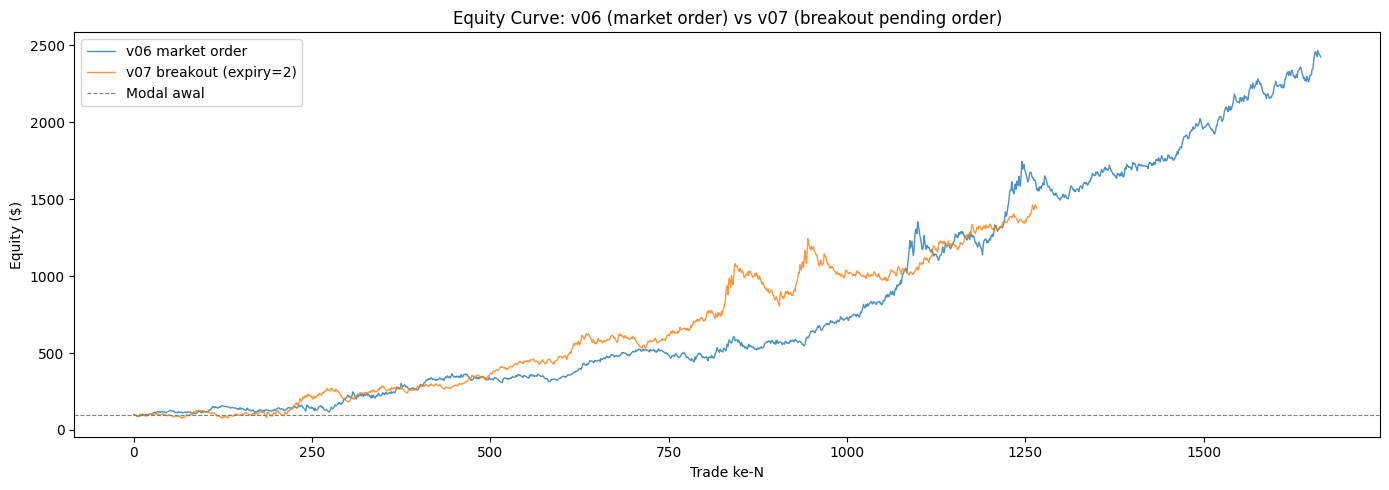

In [9]:
fig, ax = plt.subplots()
ax.plot(equity_curve_v06, linewidth=1.0, label="v06 market order", alpha=0.8)
ax.plot(equity_curve_v07, linewidth=1.0, label=f"v07 breakout (expiry={best_expiry})", alpha=0.8)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve: v06 (market order) vs v07 (breakout pending order)")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve_comparison.png", dpi=120)
plt.show()

## 8. Simpan hasil

In [10]:
trades_v07.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)
expiry_df.to_csv(EXPORT_DIR / "expiry_grid_search.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Backtest v07 — XAUUSD M5 — entry breakout (pending stop order) vs market order (v06)\n")
    f.write(f"Parameter sinyal & TP/SL sama dgn v06: MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, "
            f"SL={SL_MULT}xATR, TP={TP_MULT}xATR, MAX_HOLD={MAX_HOLD_CANDLES} candle\n")
    f.write(f"Expiry terpilih: {best_expiry} candle\n\n")
    f.write("=== Full period 2025-2026 ===\n")
    f.write("v06 market order:\n")
    for k, v in metrics_v06.items():
        f.write(f"  {k}: {v}\n")
    f.write("v07 breakout:\n")
    for k, v in metrics_v07.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  n_expired: {n_expired_v07}\n")
    f.write("\n=== Khusus periode 2026 ===\n")
    f.write("v06 market order:\n")
    for k, v in metrics_v06_2026.items():
        f.write(f"  {k}: {v}\n")
    f.write("v07 breakout:\n")
    for k, v in metrics_v07_2026.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  n_expired: {n_expired_2026}\n")

print("Log lengkap:", PROCESSED_OUT_DIR / "trade_log_full.csv")
print("Ringkasan & grafik:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Log lengkap: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v07\trade_log_full.csv
Ringkasan & grafik: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v07
 - equity_curve_comparison.png
 - expiry_grid_search.csv
 - metrics.txt
